In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!python unet.py utils.py

2026-03-04 20:18:31.101177: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772655511.120403    1084 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772655511.126854    1084 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772655511.145804    1084 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772655511.145839    1084 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1772655511.145844    1084 computation_placer.cc:177] computation placer alr

In [3]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use("ggplot")
%matplotlib inline

import cv2
from tqdm import tqdm_notebook, tnrange
from glob import glob
from itertools import chain
from skimage.io import imread, imshow, concatenate_images
from skimage.transform import resize
from skimage.morphology import label
from sklearn.model_selection import train_test_split

import tensorflow as tf
from skimage.color import rgb2gray
from tensorflow.keras import Input
from tensorflow.keras.models import Model, load_model, save_model
from tensorflow.keras.layers import Input, Activation, BatchNormalization, Dropout, Lambda, Conv2D, Conv2DTranspose, MaxPooling2D, concatenate
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from tensorflow.keras import backend as K
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from utils import *
from unet import *

**unet.py**

In [ ]:
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Model, load_model, save_model
from tensorflow.keras.layers import (
    Input,
    Activation,
    BatchNormalization,
    Dropout,
    Lambda,
    Conv2D,
    Conv2DTranspose,
    MaxPooling2D,
    concatenate,
)
from tensorflow.keras import backend as K


def unet(input_size=(256, 256, 3)):
    """
    This function creates and returns a U-Net model. U-Net is a type of convolutional neural network
    designed for fast and precise segmentation of images. It consists of a contracting (downsampling)
    path and an expansive (upsampling) path, which gives it a U-shaped architecture.

    Parameters:
    -----------
    input_size : tuple of int
        The size of the input images. It is a 3-tuple for (height, width, channels).
        Default is (256, 256, 3).

    Returns:
    --------
    model : keras.models.Model
        The constructed U-Net model.
    """
    inputs = Input(input_size)

    # First DownConvolution / Encoder Leg will begin, so start with Conv2D
    conv1 = Conv2D(filters=64, kernel_size=(3, 3), padding="same")(inputs)
    bn1 = Activation("relu")(conv1)
    conv1 = Conv2D(filters=64, kernel_size=(3, 3), padding="same")(bn1)
    bn1 = BatchNormalization(axis=3)(conv1)
    bn1 = Activation("relu")(bn1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(bn1)

    conv2 = Conv2D(filters=128, kernel_size=(3, 3), padding="same")(pool1)
    bn2 = Activation("relu")(conv2)
    conv2 = Conv2D(filters=128, kernel_size=(3, 3), padding="same")(bn2)
    bn2 = BatchNormalization(axis=3)(conv2)
    bn2 = Activation("relu")(bn2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(bn2)

    conv3 = Conv2D(filters=256, kernel_size=(3, 3), padding="same")(pool2)
    bn3 = Activation("relu")(conv3)
    conv3 = Conv2D(filters=256, kernel_size=(3, 3), padding="same")(bn3)
    bn3 = BatchNormalization(axis=3)(conv3)
    bn3 = Activation("relu")(bn3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(bn3)

    conv4 = Conv2D(filters=512, kernel_size=(3, 3), padding="same")(pool3)
    bn4 = Activation("relu")(conv4)
    conv4 = Conv2D(filters=512, kernel_size=(3, 3), padding="same")(bn4)
    bn4 = BatchNormalization(axis=3)(conv4)
    bn4 = Activation("relu")(bn4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(bn4)

    conv5 = Conv2D(filters=1024, kernel_size=(3, 3), padding="same")(pool4)
    bn5 = Activation("relu")(conv5)
    conv5 = Conv2D(filters=1024, kernel_size=(3, 3), padding="same")(bn5)
    bn5 = BatchNormalization(axis=3)(conv5)
    bn5 = Activation("relu")(bn5)

    """ Now UpConvolution / Decoder Leg will begin, so start with Conv2DTranspose
    The gray arrows (in the above image) indicate the skip connections that concatenate the encoder feature map with the decoder, which helps the backward flow of gradients for improved training. """
    up6 = concatenate(
        [
            Conv2DTranspose(512, kernel_size=(2, 2), strides=(2, 2), padding="same")(
                bn5
            ),
            conv4,
        ],
        axis=3,
    )
    """ After every concatenation we again apply two consecutive regular convolutions so that the model can learn to assemble a more precise output """
    conv6 = Conv2D(filters=512, kernel_size=(3, 3), padding="same")(up6)
    bn6 = Activation("relu")(conv6)
    conv6 = Conv2D(filters=512, kernel_size=(3, 3), padding="same")(bn6)
    bn6 = BatchNormalization(axis=3)(conv6)
    bn6 = Activation("relu")(bn6)

    up7 = concatenate(
        [
            Conv2DTranspose(256, kernel_size=(2, 2), strides=(2, 2), padding="same")(
                bn6
            ),
            conv3,
        ],
        axis=3,
    )
    conv7 = Conv2D(filters=256, kernel_size=(3, 3), padding="same")(up7)
    bn7 = Activation("relu")(conv7)
    conv7 = Conv2D(filters=256, kernel_size=(3, 3), padding="same")(bn7)
    bn7 = BatchNormalization(axis=3)(conv7)
    bn7 = Activation("relu")(bn7)

    up8 = concatenate(
        [
            Conv2DTranspose(128, kernel_size=(2, 2), strides=(2, 2), padding="same")(
                bn7
            ),
            conv2,
        ],
        axis=3,
    )
    conv8 = Conv2D(filters=128, kernel_size=(3, 3), padding="same")(up8)
    bn8 = Activation("relu")(conv8)
    conv8 = Conv2D(filters=128, kernel_size=(3, 3), padding="same")(bn8)
    bn8 = BatchNormalization(axis=3)(conv8)
    bn8 = Activation("relu")(bn8)

    up9 = concatenate(
        [
            Conv2DTranspose(64, kernel_size=(2, 2), strides=(2, 2), padding="same")(
                bn8
            ),
            conv1,
        ],
        axis=3,
    )
    conv9 = Conv2D(filters=64, kernel_size=(3, 3), padding="same")(up9)
    bn9 = Activation("relu")(conv9)
    conv9 = Conv2D(filters=64, kernel_size=(3, 3), padding="same")(bn9)
    bn9 = BatchNormalization(axis=3)(conv9)
    bn9 = Activation("relu")(bn9)

    conv10 = Conv2D(filters=1, kernel_size=(1, 1), activation="sigmoid")(bn9)

    return Model(inputs=[inputs], outputs=[conv10])


**utils.py**

In [ ]:
import os
import random
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tensorflow.keras import backend as K

plt.style.use("ggplot")


def plot_from_img_path(rows, columns, list_img_path, list_mask_path):
    """ This function plots a grid of images and their corresponding masks from given lists of image and mask paths.
    It uses matplotlib for plotting and OpenCV for reading and processing the images.

    Parameters:
    -----------
    rows : int
        The number of rows in the plot grid.

    columns : int
        The number of columns in the plot grid.

    list_img_path : list of str
        A list of paths to the image files to be plotted.

    list_mask_path : list of str
        A list of paths to the mask files to be plotted.

    Returns:
    --------
    None

    Notes:
    ------
    The images are displayed in RGB format, and the masks are overlaid on the images
    with a transparency of 0.4. """
    fig = plt.figure(figsize=(12, 12))
    for i in range(1, rows * columns + 1):
        fig.add_subplot(rows, columns, i)
        img_path = list_img_path[i]
        mask_path = list_mask_path[i]
        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path)
        plt.imshow(image)
        plt.imshow(mask, alpha=0.4)
    plt.show()


def dice_coefficients(y_true, y_pred, smooth=100):
    """
    Computes the Dice similarity coefficient between the true and predicted values.

    The Dice coefficient is a statistical metric used to gauge the similarity of two samples.
    With a range from 0 to 1, the Dice coefficient is 1 when the two samples are identical and
    0 when they share no elements. A smoothing term is included to prevent division by zero.

    This function is typically used as a loss function for binary segmentation tasks,
    where the true and predicted values are binary masks of the same size.

    Parameters:
    -----------
    y_true : tensor
        The ground truth values. Typically a binary mask.

    y_pred : tensor
        The predicted values. Typically a binary mask.

    smooth : float, optional
        A smoothing factor to prevent division by zero. Default is 100.

    Returns:
    --------
    float
        The Dice similarity coefficient between the true and predicted values.

    Note:
    -----
    The inputs are flattened to 1D tensors before computation to handle
    both single and multi-channel inputs.
    """

    y_true_flatten = K.flatten(y_true)
    y_pred_flatten = K.flatten(y_pred)

    intersection = K.sum(y_true_flatten * y_pred_flatten)
    union = K.sum(y_true_flatten) + K.sum(y_pred_flatten)
    return (2 * intersection + smooth) / (union + smooth)


def dice_coefficients_loss(y_true, y_pred, smooth=100):
    """
    The Dice loss function for image segmentation models.

    The Dice loss is a measure of the overlap between the prediction (y_pred)
    and the ground truth (y_true). It ranges from 0 to 1, where a Dice loss
    of 1 indicates perfect overlap (i.e., a perfect segmentation), while a Dice
    loss of 0 indicates no overlap.

    The 'smooth' parameter is a small constant added to the numerator and
    denominator of the Dice coefficient to avoid division by zero errors
    and to stabilize the training.

    Parameters:
    y_true (tf.Tensor): Ground truth. Tensor of the same shape as y_pred.
    y_pred (tf.Tensor): Model prediction. Tensor output from the model.
    smooth (float, optional): A smoothing constant to avoid division by zero errors. Default is 100.

    Returns:
    float: The computed Dice loss.

    Why the negative sign here i.e. -dice_coefficients

    most optimization algorithms are designed to minimize a function rather than maximize it. Therefore, to convert the maximization problem to a minimization problem, we take the negative of the Dice coefficient. As a result, when the Dice coefficient is high (which is good), the loss is low, and when the Dice coefficient is low (which is bad), the loss is high. This allows the model to use standard optimization techniques to find the best parameters.

    """

    return -dice_coefficients(y_true, y_pred, smooth)


def iou(y_true, y_pred, smooth=100):
    """
    Calculates the Intersection over Union (IoU) between the true and predicted values.

    IoU, also known as the Jaccard Index, is a metric used to quantify the percent overlap
    between the target mask and our prediction output. It's often used in segmentation problems
    to evaluate the quality of predictions.

    This function is generally used for evaluating segmentation tasks where the true and
    predicted outputs are binary masks of the same size.

    Parameters:
    -----------
    y_true : tensor
        The ground truth values. Typically a binary mask.

    y_pred : tensor
        The predicted values. Typically a binary mask.

    smooth : float, optional
        A smoothing factor to prevent division by zero. Default is 100.

    Returns:
    --------
    float
        The Intersection over Union (IoU) between the true and predicted values.

    Note:
    -----
    The inputs are not flattened to 1D tensors before computation because Keras backend
    operations automatically broadcast the tensors to the appropriate shapes.
    """
    intersection = K.sum(y_true * y_pred)
    sum = K.sum(y_true + y_pred)
    iou = (intersection + smooth) / (sum - intersection + smooth)
    return iou

""" Why intersection = K.sum(y_true * y_pred) in above

The line intersection = K.sum(y_true * y_pred) is calculating the intersection of two sets, where the sets are represented as binary masks (for a segmentation problem). The intersection is basically the overlapping region of the two sets.

This is done by performing an element-wise multiplication between the true values (y_true) and the predicted values (y_pred). In the context of binary masks, this operation essentially counts the number of pixels where both the true and predicted masks are 1 (indicating a positive class).

This is because in a binary mask, a pixel value of 1 denotes the presence of the object of interest (in a segmentation task, for instance), and a pixel value of 0 denotes the background or absence of the object. Thus, when both y_true and y_pred are 1, it means that both the ground truth and the prediction agree that there is an object at that particular pixel location.

In the context of binary masks for a segmentation problem, the masks represent the region of interest in an image, where '1' denotes the presence of an object (or class) and '0' denotes the absence of that object (or background).

When we multiply these masks element-wise (y_true * y_pred), we are looking for places where both masks agree that there is an object of interest. If both y_true and y_pred are 1 at a given pixel, then the product is 1, indicating an intersection at that pixel. If either of them is 0 at a given pixel, then the product is 0, indicating no intersection.

By summing up all these products (K.sum(y_true * y_pred)), we are effectively counting the number of pixels where both the ground truth (y_true) and the prediction (y_pred) agree that there is an object of interest. This is the intersection of the ground truth and prediction.


The K.sum() operation then sums up all these overlapping '1's to give a single number representing the total intersection, or overlap, between the true and predicted values.
"""


def jaccard_distance(y_true, y_pred):
    """
    Function to compute the Jaccard distance between the true labels and the predicted labels.

    The Jaccard distance, which is a measure of dissimilarity between sets, is computed as one minus
    the intersection over union (IoU) of the sets. A lower Jaccard distance between the predicted labels
    and the true labels indicates a better model fit.

    Parameters:
    y_true (np.array): The ground truth label array (binary mask).
    y_pred (np.array): The predicted label array (binary mask).

    Returns:
    float: The Jaccard distance between the ground truth labels and the predicted labels.
    """

    y_true_flatten = K.flatten(y_true)
    y_pred_flatten = K.flatten(y_pred)
    return -iou(y_true_flatten, y_pred_flatten)

""" Why flatten in jaccard_distance

In the context of image segmentation tasks, the ground truth y_true and the predicted output y_pred are typically 2D arrays (for grayscale images) or 3D arrays (for color images). Each element in these arrays corresponds to a pixel in the image, and the value of the element indicates the class or label of that pixel.

However, when calculating metrics such as the Jaccard distance or intersection over union (IoU), we're typically interested in comparing the sets of pixels that belong to each class, without considering their spatial arrangement in the image. Therefore, it's common to flatten the arrays to 1D before performing these calculations.

Flattening the arrays essentially transforms them into long lists of pixel values, disregarding the original spatial structure of the image. This allows us to treat the problem as a simple set comparison, where we're only interested in whether each pixel belongs to each class, not where the pixel is located in the image.

To summarize, flattening the arrays in this context simplifies the calculation of set-based metrics and focuses the evaluation on the pixel-wise accuracy of the segmentation, rather than the spatial accuracy. """

In [4]:
# Setting size parameters of images
im_width = 256
im_height = 256

**Loading the image and mask paths**

In [5]:
from glob import glob
import os

BASE_PATH = "/content/drive/MyDrive/dat"

mask_files = glob(os.path.join(BASE_PATH, "M", "*_mask*"))

image_filenames_train = []

for mask_path in mask_files:

    # Get only file name (example: image_1_mask.png)
    filename = os.path.basename(mask_path)

    # Remove "_mask"
    image_name = filename.replace("_mask", "")

    # Build correct image path inside img folder
    image_path = os.path.join(BASE_PATH, "img", image_name)

    # Optional safety check
    if os.path.exists(image_path):
        image_filenames_train.append(image_path)
    else:
        print("Missing image:", image_path)

print(image_filenames_train[:10])
print(len(image_filenames_train))

['/content/drive/MyDrive/dat/img/87.jpg', '/content/drive/MyDrive/dat/img/77.jpg', '/content/drive/MyDrive/dat/img/99.jpg', '/content/drive/MyDrive/dat/img/98.jpg', '/content/drive/MyDrive/dat/img/78.jpg', '/content/drive/MyDrive/dat/img/75.jpg', '/content/drive/MyDrive/dat/img/278.jpg', '/content/drive/MyDrive/dat/img/96.jpg', '/content/drive/MyDrive/dat/img/71.jpg', '/content/drive/MyDrive/dat/img/90.jpg']
68


**Plotting few images and masks**

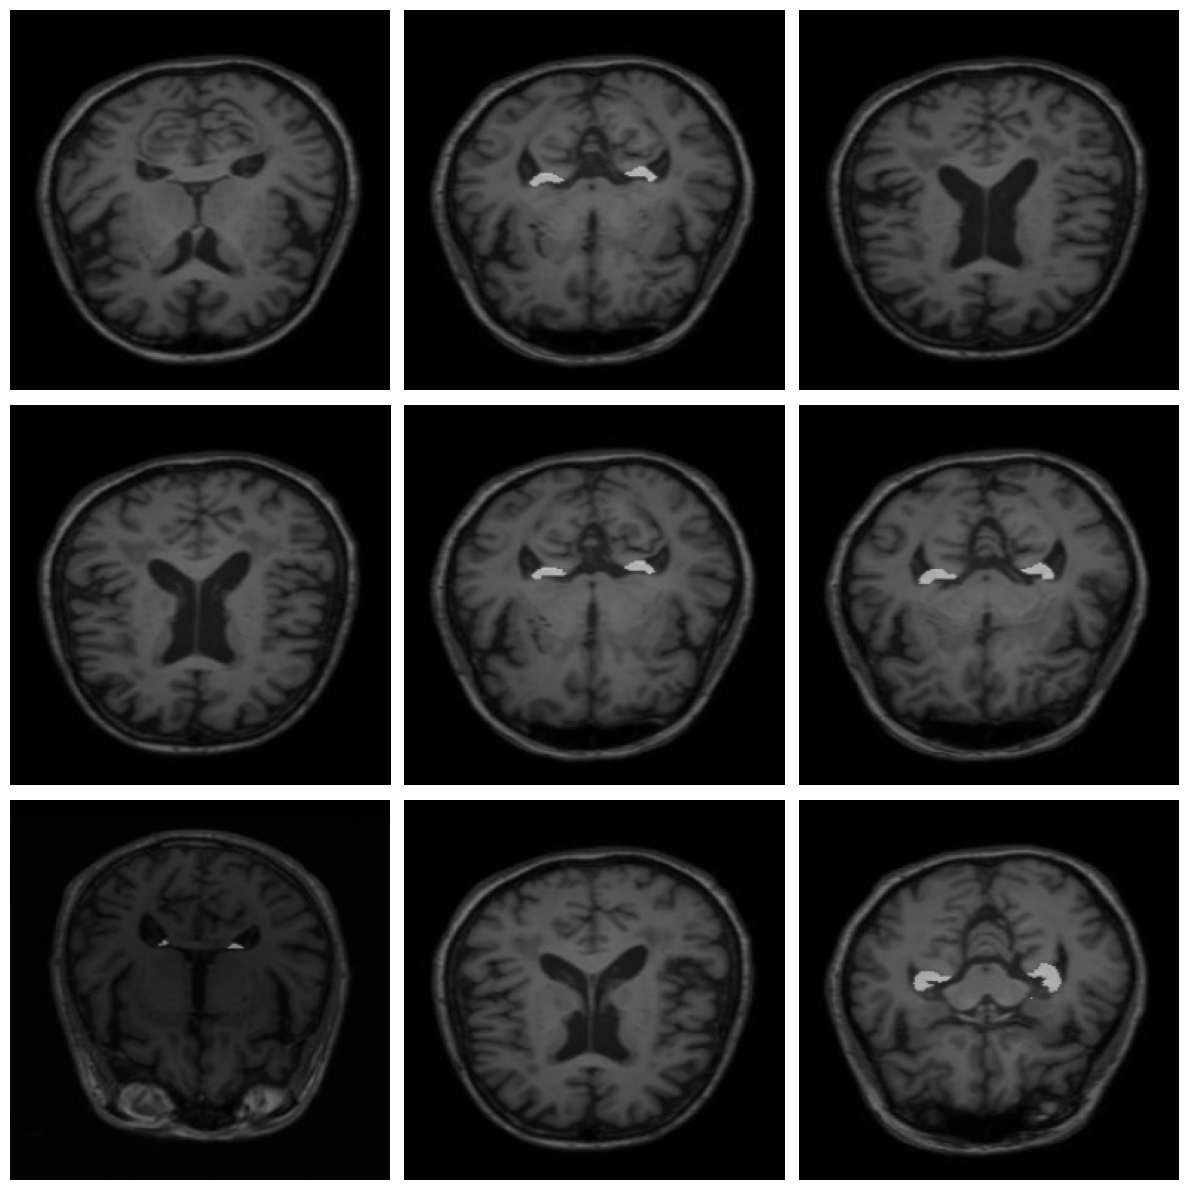

In [6]:
def plot_from_img_path(rows, columns, list_img_path, list_mask_path):
    fig = plt.figure(figsize=(12, 12))

    total = min(len(list_img_path), len(list_mask_path), rows * columns)

    for i in range(total):
        fig.add_subplot(rows, columns, i + 1)

        img_path = list_img_path[i]
        mask_path = list_mask_path[i]

        image = cv2.imread(img_path)
        mask = cv2.imread(mask_path)

        if image is None:
            print("Image not found:", img_path)
            continue

        if mask is None:
            print("Mask not found:", mask_path)
            continue

        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        plt.imshow(image)
        plt.imshow(mask, alpha=0.4)
        plt.axis("off")

    plt.tight_layout()
    plt.show()
plot_from_img_path(3, 3 , image_filenames_train, mask_files )


**Create data frame and split data on train set, validation set and test set**

In [ ]:
df = pd.DataFrame({
    'image': image_filenames_train,
    'mask': mask_files
})

# First split: train + test (10% test)
df_train, df_test = train_test_split(
    df,
    test_size=0.1,
    random_state=42,
    shuffle=True
)

# Second split: train + validation (20% of remaining train)
df_train, df_val = train_test_split(
    df_train,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Train shape:", df_train.shape)
print("Validation shape:", df_val.shape)
print("Test shape:", df_test.shape)



**Data genertator, data augmentation and adjust data**

In [8]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def train_generator(
    data_frame,
    batch_size,
    augmentation_dict,
    image_color_mode="rgb",
    mask_color_mode="grayscale",
    target_size=(256, 256),
    seed=1,
):

    image_datagen = ImageDataGenerator(**augmentation_dict)
    mask_datagen = ImageDataGenerator(**augmentation_dict)

    image_generator = image_datagen.flow_from_dataframe(
        data_frame,
        x_col="image",
        class_mode=None,
        color_mode=image_color_mode,
        target_size=target_size,
        batch_size=batch_size,
        seed=seed,
    )

    mask_generator = mask_datagen.flow_from_dataframe(
        data_frame,
        x_col="mask",
        class_mode=None,
        color_mode=mask_color_mode,
        target_size=target_size,
        batch_size=batch_size,
        seed=seed,
    )

    train_gen = zip(image_generator, mask_generator)

    for (img, mask) in train_gen:
        img, mask = normalize_and_diagnose(img, mask)
        yield (img, mask)

In [10]:
def normalize_and_diagnose(img, mask):
    img = img / 255
    mask = mask / 255
    mask[mask > 0.5] = 1
    mask[mask <= 0.5] = 0
    return(img, mask)
EPOCHS = 100
BATCH_SIZE = 32
learning_rate = 1e-4
smooth=100

In [11]:
model = unet()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │      1,792 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ conv2d[0][0]      │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ conv2d_2[0][0]    │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 64, 64,    │          0 │ conv2d_4[0][0]    │
│ (Activation)        │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 64, 64,    │    590,080 │ activation_4[0][… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_5[0][0]  

 Total params: 31,043,521 (118.42 MB)

 Trainable params: 31,037,633 (118.40 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [ ]:
from keras.optimizers import Adam
from keras.callbacks import ModelCheckpoint

# ---------------------------
# Data Augmentation Parameters
# ---------------------------
train_generator_param = dict(
    rotation_range=0.2,
    width_shift_range=0.05,
    height_shift_range=0.05,
    shear_range=0.05,
    zoom_range=0.05,
    horizontal_flip=True,
    fill_mode='nearest'
)

# ---------------------------
# Generators
# ---------------------------
train_gen = train_generator(
    df_train,
    BATCH_SIZE,
    train_generator_param,
    target_size=(im_height, im_width)
)

test_gen = train_generator(
    df_val,
    BATCH_SIZE,
    dict(),
    target_size=(im_height, im_width)
)

# ---------------------------
# Model
# ---------------------------
model = unet(input_size=(im_height, im_width, 3))

# ---------------------------
# Optimizer (Fixed for Keras 3)
# ---------------------------
opt = Adam(learning_rate=learning_rate)

# ---------------------------
# Compile
# ---------------------------
model.compile(
    optimizer=opt,
    loss=dice_coefficients_loss,
    metrics=["binary_accuracy", iou, dice_coefficients]
)

# ---------------------------
# Callbacks
# ---------------------------
callbacks = [
    ModelCheckpoint(
        filepath="unet.keras",   # recommended format in Keras 3
        monitor="val_loss",
        save_best_only=True,
        verbose=1
    )
]

# ---------------------------
# Train
# ---------------------------
history = model.fit(
    train_gen,
    steps_per_epoch=len(df_train) // BATCH_SIZE,
    epochs=EPOCHS,
    callbacks=callbacks,
    validation_data=test_gen,
    validation_steps=len(df_val) // BATCH_SIZE
)

In [ ]:
history_post_training = history.history

train_dice_coeff_list = history_post_training['dice_coefficient']
test_dice_coeff_list = history_post_training['val_dice_coefficient']

train_jaccard_list = history_post_training['iou']
test_jaccard_list = history_post_training['val_iou']

train_loss_list = history_post_training['loss']
test_loss_list = history_post_training['val_loss']

plt.figure(1)
plt.plot(test_loss_list, 'b-')
plt.plot(train_loss_list, 'r-')

plt.xlabel('iterations')
plt.ylabel('loss')
plt.title('loss graph', fontsize=12)

plt.figure(2)
plt.plot(train_dice_coeff_list, 'b-')
plt.plot(test_dice_coeff_list, 'r-')

plt.xlabel('iterations')
plt.ylabel('accuracy')
plt.title('Accuracy graph', fontsize=12)
plt.show()

**Load trained Model**

In [ ]:
model = load_model('unet.keras', custom_objects={'dice_coefficient_loss': dice_coefficients_loss, 'iou': iou, 'dice_coefficient': dice_coefficients  } )

In [ ]:
test_gen = train_generator(df_test, BATCH_SIZE, dict(), target_size=(im_height, im_width)  )

results = model.evaluate(test_gen, steps=len(df_test) / BATCH_SIZE )

print('Test Loss ', results[0] )
print('Test IoU ', results[1] )
print('Test Dice Coefficient ', results[2] )

**Plotting Predicted Masks Segmentation results from the Test Image set**

In [ ]:
for i in range(20):
    index = np.random.ranint(1, len(df_test.index))
    img = cv2.imread(df_test['image_filenames_train'].iloc[index])
    img = cv2.resize(img, (im_height, im_width))
    img = img/255
    # print(imgs.shape) (256, 256 , 3)
    img = img[np.newaxis, :, :, : ]
    # print(img.shape) # (1, 256, 256, 3)

    predicted_img = model.predict(img)

    plt.figure(figsize=(12, 12))
    plt.subplot(1, 3, 1)
    plt.imshow(np.squeeze(img))
    plt.title('Original Image')

    plt.subplot(1, 3, 2)
    plt.imshow(np.squeeze(cv2.imread(df_test['mask'].iloc[index])))
    plt.title('Original Mask')

    plt.subplot(1, 3, 3)
    plt.imshow(np.squeeze(predicted_img) > 0.5 )
    plt.title('Prediction')
    plt.show()
